In [141]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import scienceplots
import matplotlib.image as mpimg
import numpy as np
 

In [142]:
EVENTS_FOLDER_q    = r"C:\Arjun\Thesis\data\20200422_172431-sunset2\unormal_subs"
EVENTS_FOLDER_r  = r"C:\Arjun\Thesis\data\20200421_170039-sunset1\filtered chunks\un-normalised"   # folder containing events_batch_*.csv
'''START_TIMESTAMP  = 1587452746.1 #65352 #1587540465.7    # start of integration window  (same units as CSV timestamps)
TIME_PERIOD      = 1.4
END_TIMESTAMP = START_TIMESTAMP + TIME_PERIOD'''

# DAVIS resolution
WIDTH, HEIGHT = 346, 260

In [143]:
#subsampled
def filt_df(EVENTS_FOLDER, START_TIMESTAMP, TIME_PERIOD):
    import glob, os
    END_TIMESTAMP = START_TIMESTAMP + TIME_PERIOD
    # Load and concatenate all batch CSVs
    all_files = sorted(glob.glob(os.path.join(EVENTS_FOLDER, "filtered_events_batch_*.csv")))
    df = pd.concat([pd.read_csv(f) for f in all_files], ignore_index=True)
    df.columns = df.columns.str.strip().str.lower()

    # Filter to the time window
    df = df[(df["timestamp"] >= START_TIMESTAMP) & (df["timestamp"] <= END_TIMESTAMP)]
    top_density = True
    number = int(25*TIME_PERIOD/0.1)
    if top_density:
        df = df.nlargest(number, "density_value")

    print(f"Events in window: {len(df)}")
    print(df.head())
    return df

In [144]:
def filt_df_v2(EVENTS_FOLDER, START_TIMESTAMP, TIME_PERIOD, events_per_window=25, window_size_sec=0.1):
    import glob, os
    END_TIMESTAMP = START_TIMESTAMP + TIME_PERIOD

    # Load and concatenate all batch CSVs
    all_files = sorted(glob.glob(os.path.join(EVENTS_FOLDER, "filtered_events_batch_*.csv")))
    df = pd.concat([pd.read_csv(f) for f in all_files], ignore_index=True)
    df.columns = df.columns.str.strip().str.lower()

    # Filter to the time window
    df = df[(df["timestamp"] >= START_TIMESTAMP) & (df["timestamp"] <= END_TIMESTAMP)]

    # Convert to numpy array: [x, y, polarity, timestamp, density_value]
    events_ts = df[["x", "y", "polarity", "timestamp", "density_value"]].to_numpy()

    # Sort by timestamp
    sort_indices = np.argsort(events_ts[:, 3])
    events_ts_sorted = events_ts[sort_indices]

    min_time = events_ts_sorted[0, 3]
    max_time = events_ts_sorted[-1, 3]
    num_windows = int(np.ceil((max_time - min_time) / window_size_sec))

    print(f"\n  Windowed density subsampling:")
    print(f"    Original events : {len(events_ts_sorted)}")
    print(f"    Time range      : {min_time:.3f} to {max_time:.3f}s")
    print(f"    Windows         : {num_windows} x {window_size_sec}s")
    print(f"    Keeping top     : {events_per_window} events/window")

    selected_indices = []
    for i in range(num_windows):
        window_start = min_time + (i * window_size_sec)
        window_end   = window_start + window_size_sec

        mask = (events_ts_sorted[:, 3] >= window_start) & (events_ts_sorted[:, 3] < window_end)
        window_idx = np.where(mask)[0]

        if len(window_idx) == 0:
            continue

        if len(window_idx) <= events_per_window:
            selected_indices.extend(window_idx)
        else:
            density_vals = events_ts_sorted[window_idx, 4]
            top_local    = np.argsort(density_vals)[-events_per_window:]
            selected_indices.extend(window_idx[top_local])

    selected_indices = sorted(selected_indices)

    # Reconstruct DataFrame in original timestamp order
    df_sub = pd.DataFrame(
        events_ts_sorted[selected_indices],
        columns=["x", "y", "polarity", "timestamp", "density_value"]
    )
    df_sub["polarity"] = df_sub["polarity"].astype(int)

    print(f"    After subsampling: {len(df_sub)} events")
    print(f"    Reduction        : {(1 - len(df_sub)/len(events_ts_sorted))*100:.1f}%")

    return df_sub

In [145]:
df = filt_df_v2(EVENTS_FOLDER_q,1587540465.7,1 ) # query
print(f"len of query {len(df)}")
df_true_q  = df[df["polarity"] == True].copy()

df = filt_df_v2(EVENTS_FOLDER_r,1587452747.65352,1)  # wrong
print(f"len of ref {len(df)}")
df_true_r = df[df["polarity"] == True].copy()

df = filt_df_v2(EVENTS_FOLDER_r,1587452791.35,1)  # correct
print(f"len of correct {len(df)}")
df_true_c = df[df["polarity"] == True].copy()


  Windowed density subsampling:
    Original events : 1595
    Time range      : 1587540465.700 to 1587540466.700s
    Windows         : 10 x 0.1s
    Keeping top     : 25 events/window
    After subsampling: 250 events
    Reduction        : 84.3%
len of query 250

  Windowed density subsampling:
    Original events : 302
    Time range      : 1587452747.654 to 1587452748.653s
    Windows         : 10 x 0.1s
    Keeping top     : 25 events/window
    After subsampling: 239 events
    Reduction        : 20.9%
len of ref 239

  Windowed density subsampling:
    Original events : 195
    Time range      : 1587452791.353 to 1587452792.344s
    Windows         : 10 x 0.1s
    Keeping top     : 25 events/window
    After subsampling: 171 events
    Reduction        : 12.3%
len of correct 171


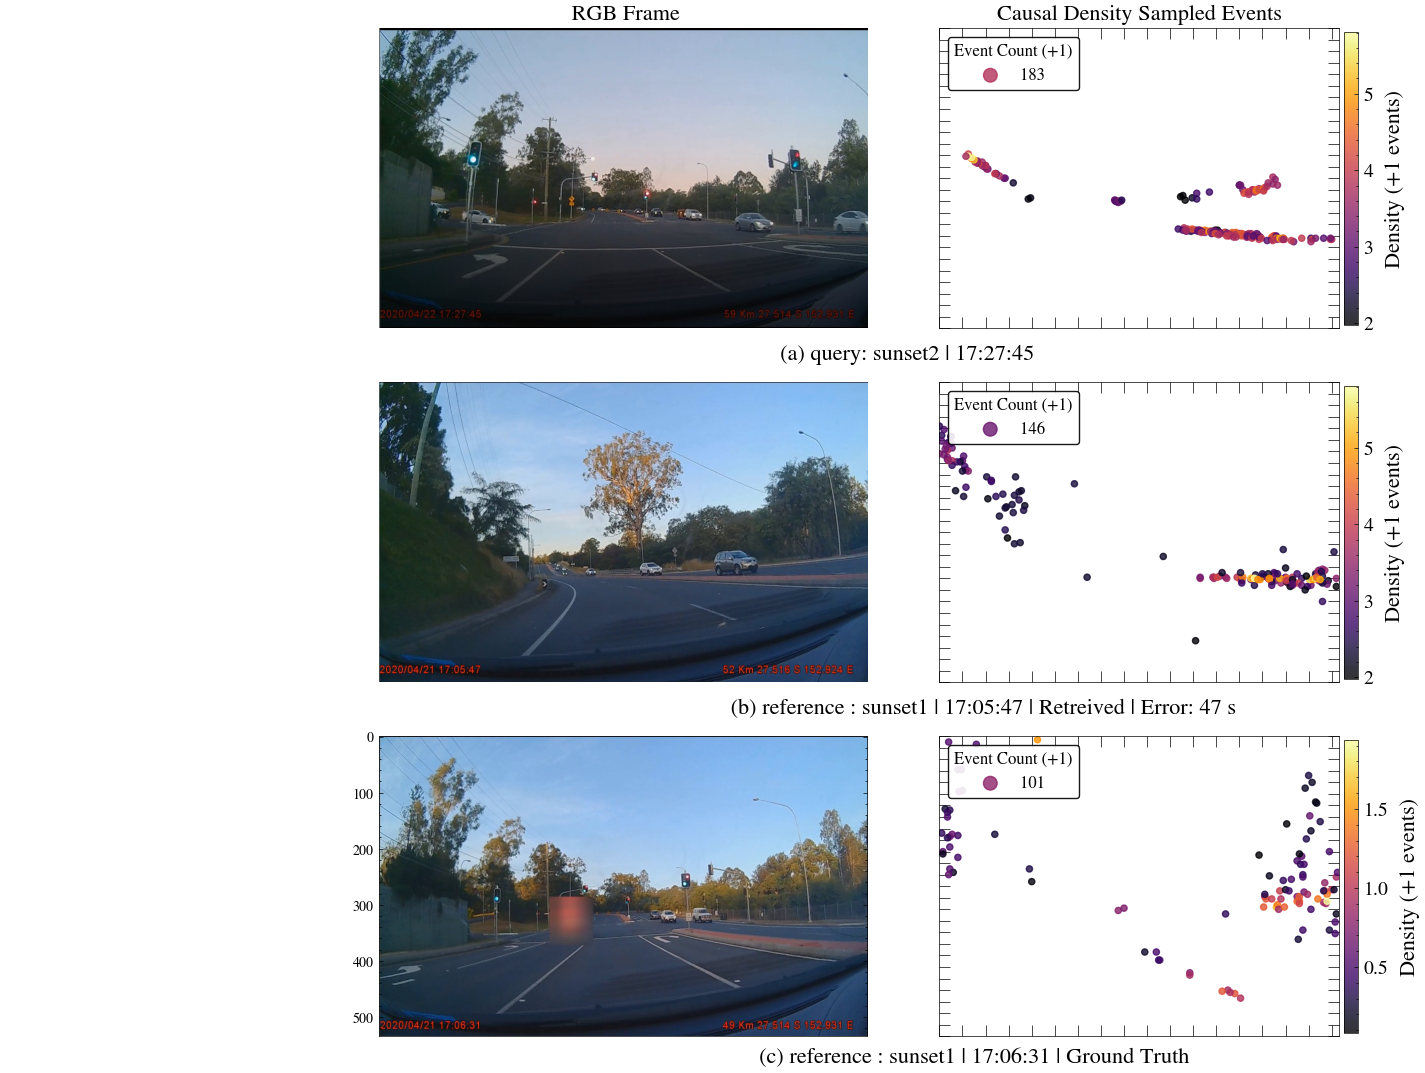

In [195]:
plt.style.use(['science', 'no-latex'])
fig, axes = plt.subplots(3,2,figsize=(11,12))
#plt.subplots_adjust(hspace=0.0005)
ax_img_top_q   = axes[0, 0]   # top-left:     image
ax_scatter_top_q = axes[0, 1]  # top-right:    scatter (+1 events)
ax_img_bot_r   = axes[1, 0]   # bottom-left:  image
ax_scatter_bot_r = axes[1, 1]
ax_img_wrong = axes[2, 0] 
ax_scatter_wrong = axes[2, 1] 

ax_img_top_q.set_title(" RGB Frame", fontsize=16)
ax_scatter_top_q.set_title("Causal Density Sampled Events", fontsize=16)

ax_img_bot_r.set_title("\t (a) query: sunset2 | 17:27:45".expandtabs(100), fontsize=16,pad=16)
ax_img_wrong.set_title("\t (b) reference : sunset1 | 17:05:47 | Retreived | Error: 47 s ".expandtabs(128), fontsize=16,pad=16)

# --- FALSE events: plain grey markers, no colormap ---
img_q_path = r"C:\Arjun\Thesis\Draft\figures\query_failed.jpg"  # <-- replace
img_r_path = r"C:\Arjun\Thesis\Draft\figures\ref_failed.jpg"
img_wrong = r"C:\Arjun\Thesis\Draft\figures\wrong.jpg"

img_top = mpimg.imread(img_q_path)
ax_img_top_q .imshow(img_top, aspect='auto')
ax_img_top_q.axis("off")

img_bot = mpimg.imread(img_r_path)
ax_img_bot_r.imshow(img_bot, aspect='auto')
ax_img_bot_r.axis("off")

img_w = mpimg.imread(img_wrong)
ax_img_wrong.imshow(img_w, aspect='auto')
ax_img_wrong.xaxis.set_visible(False)
#ax_img_wrong.set_xlabel("\t (c) reference : sunset1 | 17:06:31 | Ground Truth ".expandtabs(124))



#true data
sc0=ax_scatter_top_q.scatter(
    df_true_q["x"], df_true_q["y"],
    c=df_true_q["density_value"],
    cmap="inferno", 
    s=20,
    alpha=0.8,
    label=f"{len(df_true_q)}  ",
    zorder=2,
    norm=mcolors.Normalize(
        vmin=df_true_q["density_value"].min(),
        vmax=df_true_q["density_value"].max(),
    )
)
ax_scatter_top_q.legend(frameon=True, title="Event Count (+1)", loc="upper left",
                      markerscale=2.2, framealpha=0.9, edgecolor="black",
                      fontsize=12, title_fontsize=12)
ax_scatter_top_q.set_xticklabels([])
ax_scatter_top_q.set_yticklabels([])

cbar = fig.colorbar(sc0, ax=ax_scatter_top_q, pad=0.01,fraction=0.03)
cbar.ax.tick_params(labelsize=14)
cbar.set_label("Density (+1 events)", fontsize=16, labelpad=8)

#ax_scatter_top_q.set_ylabel("Y", fontsize=16)
ax_scatter_top_q.tick_params(axis='both', labelsize=14, which='both', length=8)
ax_scatter_top_q.set_xlim(0, 346)
ax_scatter_top_q.set_ylim(260, 0)
ax_scatter_top_q.set_aspect("equal")



sc1=ax_scatter_bot_r.scatter(
    df_true_r["x"], df_true_r["y"],
    c=df_true_r["density_value"],
    cmap="inferno", 
    s=20,
    alpha=0.8,
    label=f"{len(df_true_r)}  ",
    zorder=2,
    norm=mcolors.Normalize(
        vmin=df_true_r["density_value"].min(),
        vmax=df_true_r["density_value"].max(),
    )
)

ax_scatter_bot_r.legend(frameon=True, title="Event Count (+1)", loc="upper left",
                      markerscale=2.2, framealpha=0.9, edgecolor="black",
                      fontsize=12, title_fontsize=12)
cbar = fig.colorbar(sc0, ax=ax_scatter_bot_r, pad=0.01,fraction=0.03)
cbar.ax.tick_params(labelsize=14)
cbar.set_label("Density (+1 events)", fontsize=16, labelpad=8)

#ax_scatter_bot_r.set_ylabel("Y", fontsize=16)
ax_scatter_bot_r.tick_params(axis='both', labelsize=14, which='both', length=8)
ax_scatter_bot_r.set_xticklabels([])
ax_scatter_bot_r.set_yticklabels([])

ax_scatter_bot_r.set_xlim(0, 346)
ax_scatter_bot_r.set_ylim(260, 0)
ax_scatter_bot_r.set_aspect("equal")


sc2=ax_scatter_wrong.scatter(
    df_true_c ["x"], df_true_c ["y"],
    c=df_true_c["density_value"],
    cmap="inferno", 
    s=20,
    alpha=0.8,
    label=f"{len(df_true_c)}  ",
    zorder=2,
    norm=mcolors.Normalize(
        vmin=df_true_c["density_value"].min(),
        vmax=df_true_c["density_value"].max(),
    )
)
ax_scatter_wrong.legend(frameon=True, title="Event Count (+1)", loc="upper left",
                      markerscale=2.2, framealpha=0.9, edgecolor="black",
                      fontsize=12, title_fontsize=12)
ax_scatter_wrong.set_xticklabels([])
ax_scatter_wrong.set_yticklabels([])

cbar = fig.colorbar(sc2, ax=ax_scatter_wrong, pad=0.01,fraction=0.03)
cbar.ax.tick_params(labelsize=14)
cbar.set_label("Density (+1 events)", fontsize=16, labelpad=8)

#ax_scatter_top_q.set_ylabel("Y", fontsize=16)
ax_scatter_wrong.tick_params(axis='both', labelsize=14, which='both', length=8)
ax_scatter_wrong.set_xlim(0, 346)
ax_scatter_wrong.set_ylim(260, 0)
ax_scatter_wrong.set_aspect("equal")
#ax_scatter_wrong.set_xlabel("")

    # remove if your x/y scales differ a lot

#plt.tight_layout()
fig.subplots_adjust(hspace=0.18,wspace=0.005,top=0.95,left=0.01)
fig.suptitle("\t (c) reference : sunset1 | 17:06:31 | Ground Truth ".expandtabs(20),y=0.1, fontsize=16)
plt.savefig("events_plot.png", dpi=150)   # optional save
plt.show()

In [147]:
#For original data
import glob, os
EVENTS_FOLDER = r"C:\Arjun\Thesis\data\20200422_172431-sunset2\filtered"
# Load and concatenate all batch CSVs
all_files = sorted(glob.glob(os.path.join(EVENTS_FOLDER, "events_batch_*.csv")))

chunks = []

for f in all_files:
    chunk = pd.read_csv(f)
    chunk.columns = chunk.columns.str.strip().str.lower()
    
    # Skip entire file if it ends before our window starts
    if chunk["timestamp"].max() < START_TIMESTAMP:
        continue
    
    # Stop entirely if this file starts after our window ends
    if chunk["timestamp"].min() > END_TIMESTAMP:
        break
    
    # Keep only rows within the window
    chunk = chunk[(chunk["timestamp"] >= START_TIMESTAMP) & (chunk["timestamp"] <= END_TIMESTAMP)]
    chunks.append(chunk)

df_data = pd.concat(chunks, ignore_index=True) if chunks else pd.DataFrame()
print(f"Files used: {len(chunks)}  |  Events in window: {len(df_data)}")

Files used: 0  |  Events in window: 0


In [148]:
df_data_true  = df_data[df_data["polarity"] == True].copy()
df_data_false = df_data[df_data["polarity"] == False].copy()

print(f"TRUE : {len(df_data_true)}")
print(f"FALSE: {len(df_data_false)}")

KeyError: 'polarity'

NameError: name 'df_data_true' is not defined

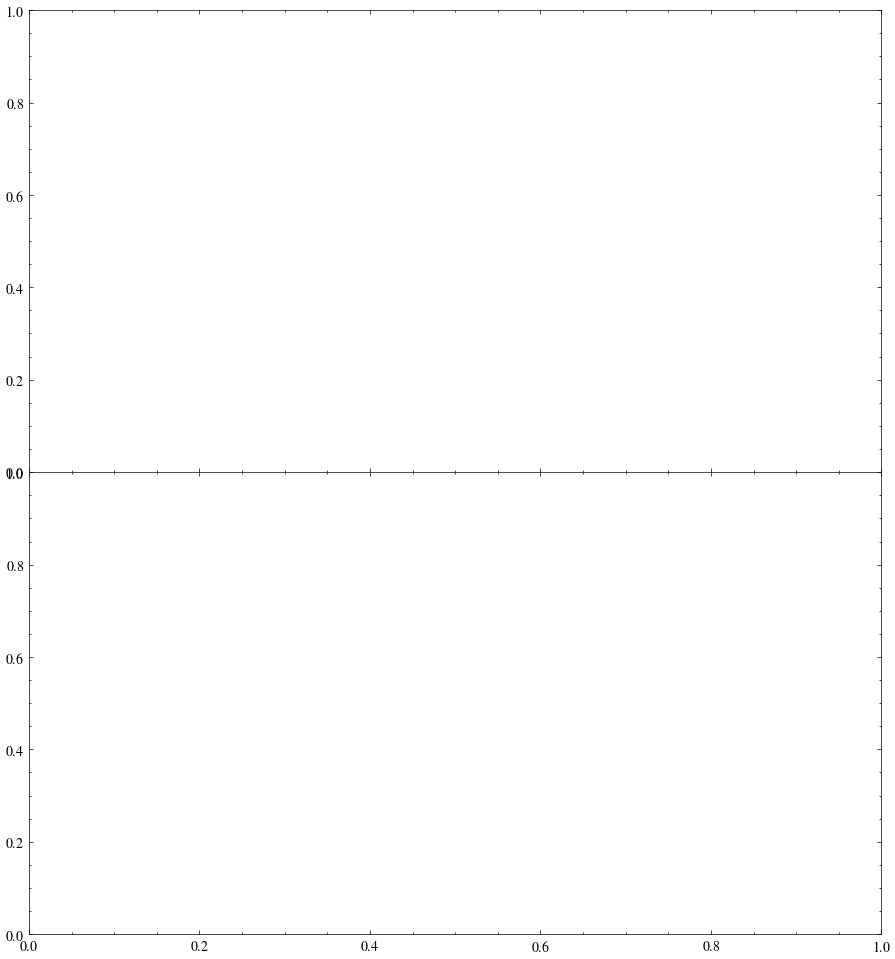

In [ ]:
plt.style.use(['science', 'no-latex'])
fig, axes = plt.subplots(2,1,figsize=(11, 12),sharex=True)
plt.subplots_adjust(hspace=0.0005)
ax=axes.ravel()

# --- FALSE events: plain grey markers, no colormap ---


#true data
sc0=ax[0].scatter(
    df_data_true["x"], df_data_true["y"],
    c = "gray", #salmon
    marker='+',
    s=20,
    alpha=0.8,
    label=f" Raw events: {len(df_data_true)}  ",
    zorder=1,
)

sc2=ax[1].scatter(
    df_data_false["x"], df_data_false["y"],
    c = "gray",
    marker='+',
    s=20,
    alpha=0.8,
    label=f" Raw events: {len(df_data_false)} ",
    zorder=1,
)
# --- TRUE events:density-
sc1 = ax[0].scatter(
    df_true["x"], df_true["y"],
    c=df_true["density_value"],
    cmap="inferno",          # change to "viridis", "hot", etc. if preferred
    s=20,
    alpha=0.8,
    label=f"Subsampled : {len(df_true)} ({np.round((1-(len(df_true)/len(df_data_true)))*100,decimals=1)}%)",
    zorder=2,
    norm=mcolors.Normalize(
        vmin=df_true["density_value"].min(),
        vmax=df_true["density_value"].max(),
    ),
)

#ax[0].text(5,np.max(df_true["y"]),'Total Count')

sc3=ax[1].scatter(
    df_false["x"], df_false["y"],
    c=df_false["density_value"],
    cmap="viridis",
    s=20,
    alpha=0.8,
    label=f"Subsampled: {len(df_false)} ({np.round((1-(len(df_false)/len(df_data_false)))*100,decimals=1)}%)",
    zorder=1,
)

ax[0].legend(frameon=True,title = "Event Count (+1)",loc="upper left",markerscale=2.2,framealpha=0.9,edgecolor="black", fontsize =12,title_fontsize =12 )
ax[1].legend(frameon=True, title = "Event Count (-1)",loc="upper left",markerscale=2.2,framealpha=0.9,edgecolor="black", fontsize =12,title_fontsize =12)
cbar = fig.colorbar(sc1, ax=ax[0], pad=0.01)
cbar.ax.tick_params(labelsize=14)
cbar.set_label("Density (+1 events)", fontsize=16, labelpad = 8)

cbar1 = fig.colorbar(sc3, ax=ax[1], pad=0.01)
cbar1.ax.tick_params(labelsize=14)
cbar1.set_label("Density (-1 events)", fontsize=16, labelpad = 8)

ax[1].set_xlabel("X", fontsize=16)
ax[1].tick_params(axis='both',labelsize=14,which='both',length=8)

ax[1].set_xlim(0, 346)
ax[1].set_ylabel("Y", fontsize=16)
ax[1].set_ylim(260, 0)

ax[0].set_ylabel("Y", fontsize=16)
ax[0].tick_params(axis='both',labelsize=14,which='both',length=8)
#ax[0].set_xlabel("X", fontsize=12)
ax[0].set_xlim(0, 346)

ax[0].set_ylim(260, 0)

#ax[0].set_title("Event Plot  |  colour = density (TRUE) · grey = FALSE", fontsize=13)
#ax.legend(markerscale=3, fontsize=10)
ax[0].set_aspect("equal") 
ax[1].set_aspect("equal")     # remove if your x/y scales differ a lot

plt.tight_layout()
plt.savefig("events_plot.png", dpi=150)   # optional save
plt.show()